In [55]:
## Here I want to find the correlation function of the lightcone at redshifts 4, 5, 6, 7, 8, 9, 10.
## Lightcone used is 'bh_coordinates_lightcone_v3.npy' in "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import numpy.ma as ma
from Corrfunc.theory.DD import DD
from sklearn.neighbors import KernelDensity

# Define the data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/'

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')

# define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = 0.7

# Import the lightcone data
Lightcone1e91e10 = np.load('/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/Lightcone_lumcut1e91e10.npy')
Lightcone1e101e11 = np.load('/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/Lightcone_lumcut1e101e11.npy')
Lightcone1e111e12 = np.load('/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/Lightcone_lumcut1e111e12.npy')

In [56]:
#----------------------------------------------------------------------------------------------------------------
# This whole section is done in a similar way to when I was creating the lightcone.

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = pixel_size_x

# Define the redshifts.
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# Define the redshifts for each slice of the lightcone.
new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

# Calculate the number of slices
new_num_slices = len(new_z_axis)

# Define the pixel centers
pixel_centers_x = np.linspace(x_range[0] + pixel_size_x / 2, x_range[1] - pixel_size_x / 2, num_pixels_x)
pixel_centers_y = np.linspace(y_range[0] + pixel_size_y / 2, y_range[1] - pixel_size_y / 2, num_pixels_y)
pixel_centers_z = np.copy(new_z_axis)

#--------------------------------------------------------------------------------------------------------------

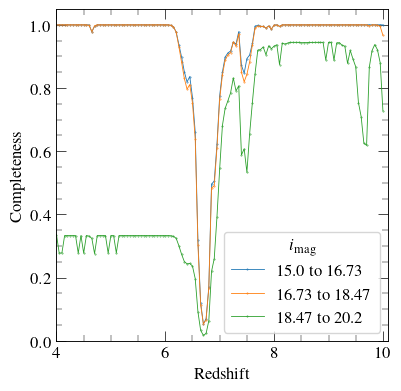

In [71]:
from astropy.io import ascii

# Make a completeness mask for the lightcone.
Lightcone1e91e10_inc = np.zeros_like(Lightcone1e91e10)

# Read Richards et al. 2006 selection function data in file Richards2006SelectionFunc.txt in data directory.
Richards2006SelectionFunc = ascii.read(DATA_DIRECTORY + 'Richards2006SelectionFunc.dat')

# Add 4.0 to the redshifts in the selection function data, so that the redshifts are now from 4.0 to 10.0.
Richards2006SelectionFunc['z'] += 4.0

# Define the minimum and the maximum imag values.
imag_min = np.min(Richards2006SelectionFunc['imag'])
imag_max = np.max(Richards2006SelectionFunc['imag'])

# Make 3 bins out of the range of imag values.
imag_bins = np.linspace(imag_min, imag_max, 4)

for i in range(len(imag_bins) - 1):
    # choose only the data with imag that are within the imag_min and imag_max values.
    Richards2006SelectionFunc_lumbin = Richards2006SelectionFunc[(Richards2006SelectionFunc['imag'] >= imag_bins[i]) & (Richards2006SelectionFunc['imag'] <= imag_bins[i + 1])]

    # Group the data by the redshifts.
    Richards2006SelectionFunc_lumbin_grouped = Richards2006SelectionFunc_lumbin.group_by('z')

    # Take the average of the selection function values for each redshift.
    Richards2006SelectionFunc_lumbin_grouped_avg = Richards2006SelectionFunc_lumbin_grouped.groups.aggregate(np.mean)

    # Plot the point values as a function of redshift.
    plt.plot(Richards2006SelectionFunc_lumbin_grouped_avg['z'], Richards2006SelectionFunc_lumbin_grouped_avg['point'], '.-', linewidth=0.6, markersize=0.7, label=str(round(imag_bins[i],2)) + ' to ' + str(round(imag_bins[i + 1],2)))

plt.xlim(4, 10.1)
plt.ylim(0, 1.05)
plt.xlabel('Redshift')
plt.ylabel('Completeness')
plt.legend(title=r'$i_{\mathrm{mag}}$', loc='lower right')
plt.grid(visible=False)
plt.gca().set_box_aspect(1)

# Save the plot as a pdf file.
plt.savefig(PLOT_DIRECTORY + 'CompletenessVsRedshift.pdf', bbox_inches='tight')

In [73]:
# Add another column to the Richards2006SelectionFunc_lumbin_grouped_avg table that contains the comoving distance corresponding to each redshift.
Richards2006SelectionFunc_lumbin_grouped_avg['comoving_distance'] = cosmo.comoving_distance(Richards2006SelectionFunc_lumbin_grouped_avg['z']).value * h

# Now multiply the Lightcone1e91e10[:,:,z] by the corresponding nearest value in the Richards2006SelectionFunc_lumbin_grouped_avg['point'].
for i, z in enumerate(new_z_axis):
    Lightcone1e91e10_inc[:,:,i] = Lightcone1e91e10[:,:,i] * \
        Richards2006SelectionFunc_lumbin_grouped_avg['point'][np.abs(Richards2006SelectionFunc_lumbin_grouped_avg['comoving_distance'] - z).argmin()]

In [76]:
# Making the catalog of the lightcone
# Define the number of black holes in each pixel
n_bh = np.copy(Lightcone1e91e10_inc)

# Initialize an empty list to store the black hole coordinates
bh_coordinates = []

# Iterate over the pixels and distribute the black holes
for k in range(new_num_slices):
    for i in range(num_pixels_x):
        for j in range(num_pixels_y):
            # Get the number of black holes in the current pixel
            n = round(n_bh[i, j, k])
            
            # Generate random x, y, z coordinates for the black holes in the pixel
            x_coords = np.random.uniform(low=pixel_centers_x[i] - pixel_size_x / 2, high=pixel_centers_x[i] + pixel_size_x / 2, size=n)
            y_coords = np.random.uniform(low=pixel_centers_y[j] - pixel_size_y / 2, high=pixel_centers_y[j] + pixel_size_y / 2, size=n)
            z_coords = np.random.uniform(low=pixel_centers_z[k] - pixel_size_z / 2, high=pixel_centers_z[k] + pixel_size_z / 2, size=n)
            
            # Append the coordinates to the list
            bh_coordinates.extend(list(zip(x_coords, y_coords, z_coords)))

# Convert the list of coordinates to a numpy array
bh_coordinates = np.array(bh_coordinates)

In [77]:
bh_coordinates.shape

(1182, 3)